# Analytical Feature Map

**Aim**: generate raster-based representations of GPS trajectories by aggregating analytical features over a regular grid.

## Importing Tracklib


In [1]:
# Import the Tracklib library
import tracklib as tkl

Code running in a no shapely environment


## Loading a collection of tracks

In [2]:
tkl.ObsTime.setReadFormat("2D/2M/4Y 2h:2m:2s")

chemin = '/home/md_vandamme/tracklib/trajlib/reseau/data2/'
fmt = tkl.TrackFormat({"ext": 'CSV',
    "id_E": 1,
    "id_N": 0,
    "id_U": 3,
    "id_T": 2,
    "h": 1,
    "separator": ";",
    "srid": "ENU"})

collection = tkl.TrackSource(chemin, fmt)

total = len(collection)
print ('Number of tracks: ' + str(total))

Number of tracks: 8654


## Zoom in on a small area around a lake

We extracte tracks abiding by geometrical shape (a Rectangle) constraint are cut and returned in the next stage below:

Number of tracks near the lake: 8654


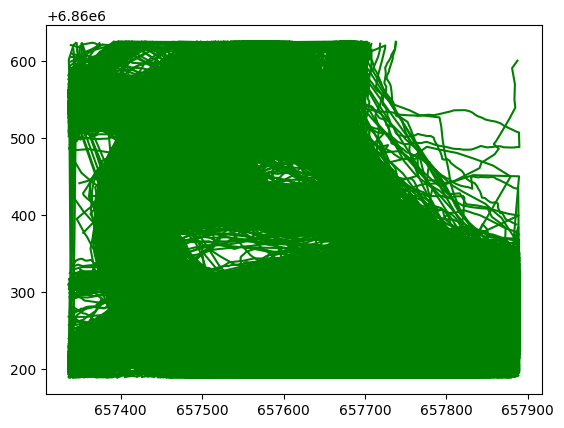

In [3]:
xMin = 657336
yMin = 6860189
xMax = 657890
yMax = 6860625

ll = tkl.ENUCoords(xMin, yMin)
ur = tkl.ENUCoords(xMax, yMax)
bbox = tkl.Rectangle(ll, ur)

constraintBBox = tkl.Constraint(shape = bbox, mode = tkl.MODE_INSIDE, type=tkl.TYPE_CUT_AND_SELECT)
lakeCollection = constraintBBox.select(collection)
print ('Number of tracks near the lake: ' + str(lakeCollection.size()))
lakeCollection.plot('g-')

## Crowd density Map

The first step is to create a **Raster**, which defines the spatial framework of the analysis through its spatial extent and cell resolution. In this example, we build a raster with a 2-meter resolution, aligned on the bounding box of the trajectory collection and without any margin.

In [4]:
margin = 0.05
resolution = (2, 2)

raster = tkl.Raster(bbox=lakeCollection.bbox(), resolution=resolution, margin=margin,
                align=tkl.BBOX_ALIGN_CENTER)

Once the raster has been created, **Analytical Feature Maps (AFMaps)** can be added. Each AFMap is associated with a single **Analytical Feature (AF)** (e.g. uid, speed, or altitude) and may contain one or several **Bands**, each computing a different statistic over the raster cells (e.g. CountBand, CountDistinctBand, MeanBand, MedianBand, DominantBand).

In this example, we compute a crowd density map by counting the number of distinct trajectories crossing each raster cell. The selected Analytical Feature is the trajectory identifier **uid**, and the statistic is computed using a **CountDistinctBand**.

In [5]:
uidMap = raster.addAFMap("uid")
uidMap.addCountDistinct()

Before rasterization, trajectories are spatially resampled at **1-meter intervals** to ensure that every crossed cell is taken into account during the accumulation process.

In [6]:
cpt = 1
for trace in lakeCollection:
    trace.uid = cpt
    trace.resample(1, mode=1)
    cpt += 1

The rasterization is then performed by accumulating the trajectory observations into the raster cells and computing the requested statistics.

In [7]:
tkl.summarize(lakeCollection, raster)
print ('Raster created.')

Raster created.


The resulting grid can be retrieved from the corresponding AFMap and displayed.

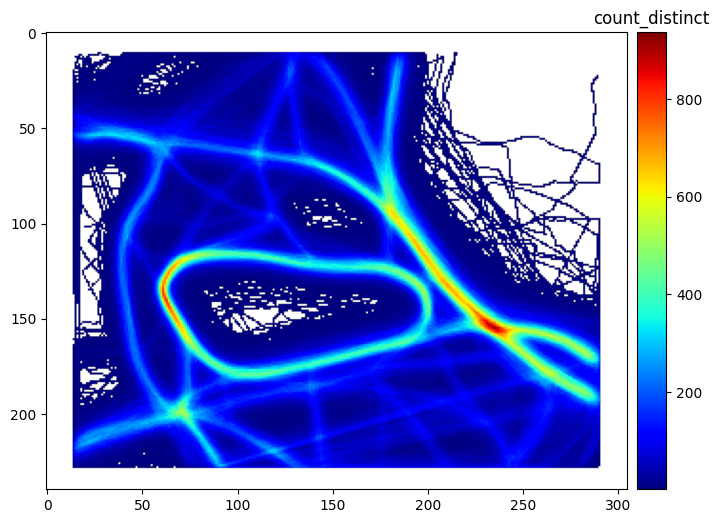

In [8]:
grid = raster.getAFMap('uid')['count_distinct']

grid.plot(cmap='jet')

## Write frequency of trajectories grid to Ascii Raster file

In [9]:
raster.writeToAscFile(grid, '/home/md_vandamme/zone_lac_2m.asc')
print ('Grid written in file.')

Grid written in file.
